<h3 align="center">Capstone project</h3>
<h1 align="center">Communities and Crime Dataset</h1>
<h3 align="center">Matúš Koleják, Branislav Trstenský</h3>

> Dataset: UCI Machine Learning Repository (ID: 183)\
> Redmond, M. (2002). Communities and Crime.\
> <https://doi.org/10.24432/C53W3X>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

Task 5: Dimensionality Reduction on Communities and Crime Dataset
=================================================================
Apply PCA, LDA, and related techniques before regression/classification.
Compare approaches, explain feature space transformations, and evaluate
whether explainable ML remains feasible after reduction.

### Load and prepare data

In [2]:
df = pd.read_csv("../data/data.csv", na_values="?")
X = df.drop("ViolentCrimesPerPop", axis=1)
y = df[["ViolentCrimesPerPop"]]

print(f"Original shape: X={X.shape}, y={y.shape}")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Original shape: X=(1994, 127), y=(1994, 1)
Features: 127, Samples: 1994


In [3]:
# Drop non-predictive columns
non_predictive = ['state', 'county', 'community', 'communityname', 'fold']
X = X.drop(columns=[c for c in non_predictive if c in X.columns], errors='ignore')

# Drop any remaining non-numeric columns
X = X.select_dtypes(include=[np.number])

# Handle missing values - drop columns with >50% missing, impute rest with median
missing_pct = X.isnull().mean()
high_missing = missing_pct[missing_pct > 0.5].index.tolist()
print(f"\nDropped {len(high_missing)} columns with >50% missing values:")
print(f"  {high_missing[:5]}... (LEMAS variables)")
X = X.drop(columns=high_missing)

# Impute remaining missing values with median
X = X.fillna(X.median())

# Target variable
y = y.values.ravel()
print(f"\nFinal shape after cleaning: X={X.shape}")
print(f"Target (ViolentCrimesPerPop): mean={y.mean():.3f}, std={y.std():.3f}")

feature_names = X.columns.tolist()



Dropped 22 columns with >50% missing values:
  ['LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq']... (LEMAS variables)

Final shape after cleaning: X=(1994, 100)
Target (ViolentCrimesPerPop): mean=0.238, std=0.233


### Standardization

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA - Principal Component Analysis

Components needed for 90% variance: 23
Components needed for 95% variance: 35
Components needed for 99% variance: 59
Total features: 100


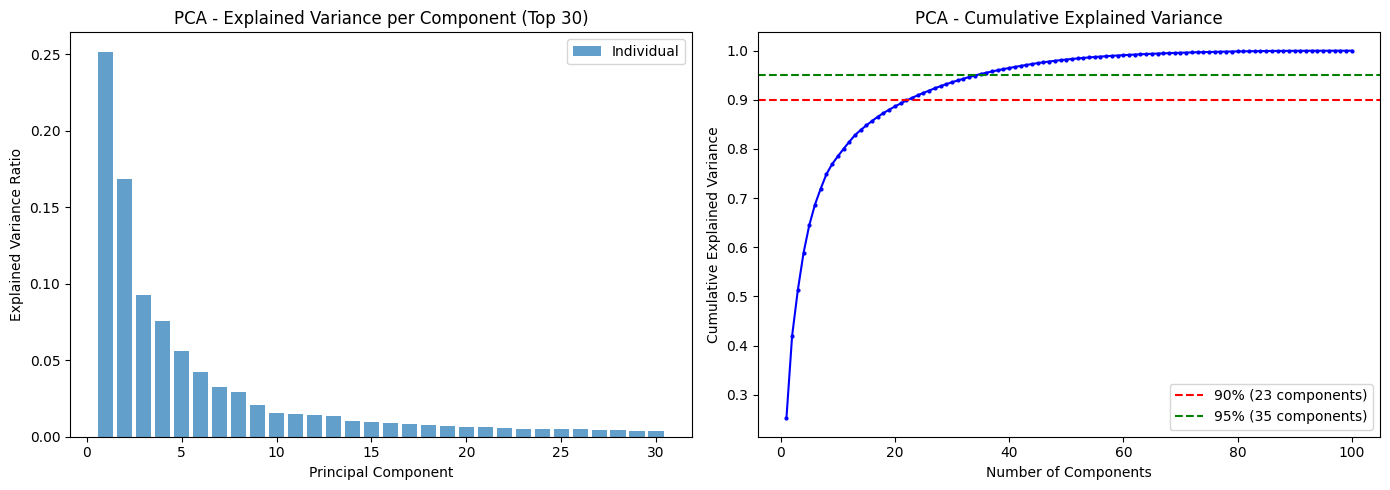

In [5]:
# Full PCA to analyze variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")
print(f"Total features: {X_scaled.shape[1]}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30], alpha=0.7, label='Individual')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA - Explained Variance per Component (Top 30)')
axes[0].legend()

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-o', markersize=2)
axes[1].axhline(y=0.90, color='r', linestyle='--', label=f'90% ({n_90} components)')
axes[1].axhline(y=0.95, color='g', linestyle='--', label=f'95% ({n_95} components)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA - Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figures/task5_pca_variance.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# PCA with chosen number of components
pca = PCA(n_components=n_95)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA reduced: {X_scaled.shape[1]} -> {X_pca.shape[1]} features (95% variance retained)")

# Top feature loadings for first 3 PCs
print("\nTop 5 feature loadings per principal component (PC1-PC3):")
for i in range(min(3, pca.n_components_)):
    loadings = pd.Series(pca.components_[i], index=feature_names)
    top_pos = loadings.nlargest(3)
    top_neg = loadings.nsmallest(3)
    print(f"\n  PC{i+1} (explains {pca.explained_variance_ratio_[i]*100:.1f}% variance):")
    print(f"    Positive: {', '.join([f'{n}({v:.3f})' for n, v in top_pos.items()])}")
    print(f"    Negative: {', '.join([f'{n}({v:.3f})' for n, v in top_neg.items()])}")


PCA reduced: 100 -> 35 features (95% variance retained)

Top 5 feature loadings per principal component (PC1-PC3):

  PC1 (explains 25.2% variance):
    Positive: medFamInc(0.183), medIncome(0.182), PctKids2Par(0.175)
    Negative: PctPopUnderPov(-0.173), pctWPubAsst(-0.164), PctHousNoPhone(-0.164)

  PC2 (explains 16.8% variance):
    Positive: PctRecImmig10(0.219), PctRecImmig8(0.219), PctRecImmig5(0.217)
    Negative: PctSpeakEnglOnly(-0.191), PctBornSameState(-0.128), pctWSocSec(-0.120)

  PC3 (explains 9.3% variance):
    Positive: PersPerOccupHous(0.254), PersPerFam(0.232), PersPerOwnOccHous(0.224)
    Negative: HousVacant(-0.170), numbUrban(-0.151), population(-0.149)


### LDA - Linear Discriminant Analysis

Target discretized into 5 classes for LDA
Class distribution: [484 315 422 387 386]
LDA reduced: 100 -> 4 features
LDA explained variance ratios: [0.83715466 0.11661786 0.02879624 0.01743124]


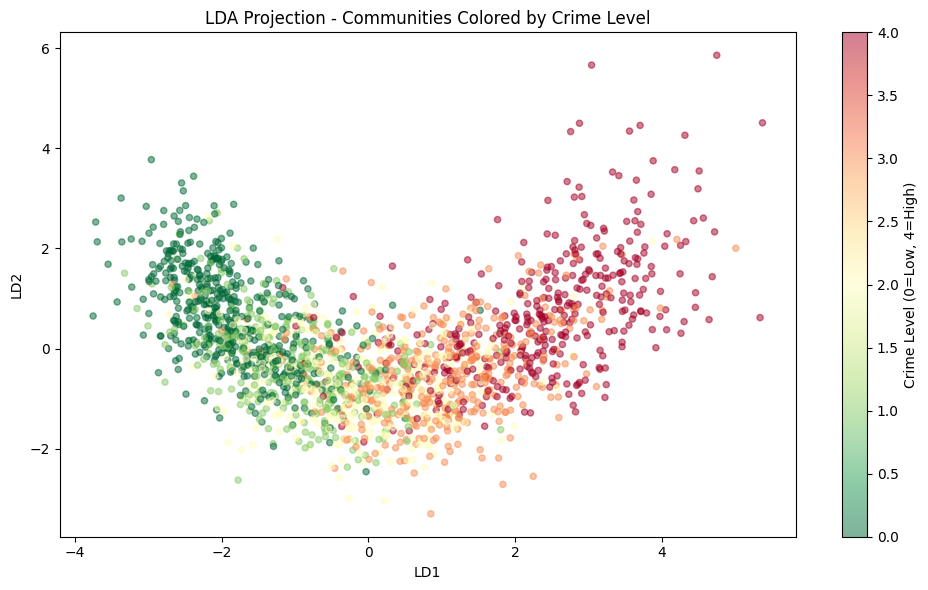

In [7]:
# LDA requires class labels - discretize target into bins
n_classes = 5
y_binned = pd.qcut(y, q=n_classes, labels=False, duplicates='drop')
actual_classes = len(np.unique(y_binned))
print(f"Target discretized into {actual_classes} classes for LDA")
print(f"Class distribution: {np.bincount(y_binned)}")

# LDA - max components = min(n_features, n_classes - 1)
max_lda_components = min(X_scaled.shape[1], actual_classes - 1)
lda = LDA(n_components=max_lda_components)
X_lda = lda.fit_transform(X_scaled, y_binned)
print(f"LDA reduced: {X_scaled.shape[1]} -> {X_lda.shape[1]} features")
print(f"LDA explained variance ratios: {lda.explained_variance_ratio_}")

# Visualize LDA projection
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_lda[:, 0], X_lda[:, 1], c=y_binned, cmap='RdYlGn_r',
                     alpha=0.5, s=20)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LDA Projection - Communities Colored by Crime Level')
plt.colorbar(scatter, label='Crime Level (0=Low, 4=High)')
plt.tight_layout()
plt.savefig('../figures/task5_lda_projection.pdf', dpi=150, bbox_inches='tight')
plt.show()

### PCA 2D Visualisation

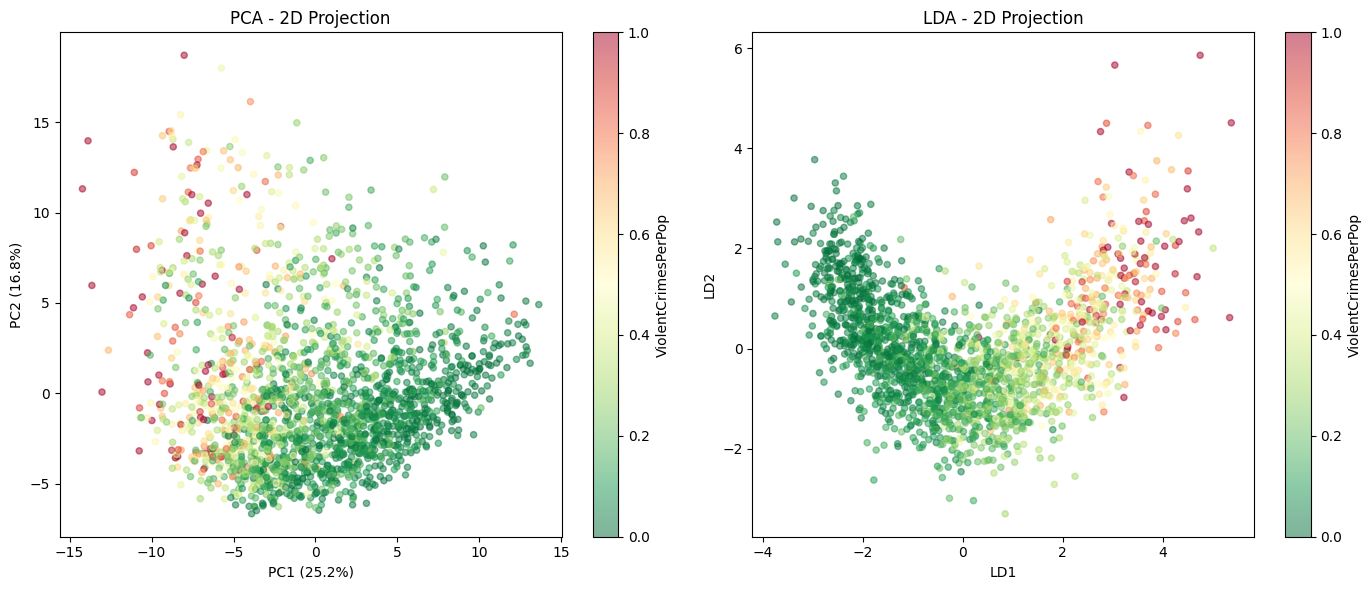

PCA 2D explains: 42.0% of total variance


In [13]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn_r',
                           alpha=0.5, s=20)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA - 2D Projection')
plt.colorbar(scatter1, ax=axes[0], label='ViolentCrimesPerPop')

scatter2 = axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='RdYlGn_r',
                           alpha=0.5, s=20)
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].set_title('LDA - 2D Projection')
plt.colorbar(scatter2, ax=axes[1], label='ViolentCrimesPerPop')

plt.tight_layout()
plt.savefig('../figures/task5_2d_projections.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("PCA 2D explains: {:.1f}% of total variance".format(
    pca_2d.explained_variance_ratio_.sum() * 100))

### REGRESSION COMPARISON: Original vs PCA-reduced

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Models to compare
results = {}

# A) Ridge Regression on original features
ridge_orig = Ridge(alpha=1.0)
scores_orig = cross_val_score(ridge_orig, X_scaled, y, cv=cv, scoring='r2')
results['Ridge (Original)'] = scores_orig
print(f"Ridge (Original {X_scaled.shape[1]} features):  R² = {scores_orig.mean():.4f} ± {scores_orig.std():.4f}")

# B) Ridge on PCA-reduced features (95% variance)
ridge_pca = Ridge(alpha=1.0)
scores_pca = cross_val_score(ridge_pca, X_pca, y, cv=cv, scoring='r2')
results['Ridge (PCA-95%)'] = scores_pca
print(f"Ridge (PCA {X_pca.shape[1]} features):          R² = {scores_pca.mean():.4f} ± {scores_pca.std():.4f}")

# C) Ridge on fewer PCA components
for n_comp in [10, 20, 30]:
    pca_n = PCA(n_components=n_comp)
    X_pca_n = pca_n.fit_transform(X_scaled)
    scores = cross_val_score(Ridge(alpha=1.0), X_pca_n, y, cv=cv, scoring='r2')
    results[f'Ridge (PCA-{n_comp})'] = scores
    print(f"Ridge (PCA {n_comp} features):              R² = {scores.mean():.4f} ± {scores.std():.4f}")

# D) Random Forest on original
rf_orig = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores_rf_orig = cross_val_score(rf_orig, X_scaled, y, cv=cv, scoring='r2')
results['RF (Original)'] = scores_rf_orig
print(f"\nRandom Forest (Original):                R² = {scores_rf_orig.mean():.4f} ± {scores_rf_orig.std():.4f}")

# E) Random Forest on PCA
rf_pca = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores_rf_pca = cross_val_score(rf_pca, X_pca, y, cv=cv, scoring='r2')
results['RF (PCA-95%)'] = scores_rf_pca
print(f"Random Forest (PCA {X_pca.shape[1]} features):  R² = {scores_rf_pca.mean():.4f} ± {scores_rf_pca.std():.4f}")

Ridge (Original 100 features):  R² = 0.6541 ± 0.0235
Ridge (PCA 35 features):          R² = 0.6426 ± 0.0263
Ridge (PCA 10 features):              R² = 0.6266 ± 0.0235
Ridge (PCA 20 features):              R² = 0.6357 ± 0.0239
Ridge (PCA 30 features):              R² = 0.6399 ± 0.0283

Random Forest (Original):                R² = 0.6432 ± 0.0382
Random Forest (PCA 35 features):  R² = 0.6140 ± 0.0248


### CLASSIFICATION COMPARISON: Original vs LDA vs PCA

In [15]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression - Original
lr_orig = LogisticRegression(max_iter=5000, random_state=42)
acc_orig = cross_val_score(lr_orig, X_scaled, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (Original {X_scaled.shape[1]} features): Acc = {acc_orig.mean():.4f} ± {acc_orig.std():.4f}")

# Logistic Regression - LDA
lr_lda = LogisticRegression(max_iter=5000, random_state=42)
acc_lda = cross_val_score(lr_lda, X_lda, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (LDA {X_lda.shape[1]} features):        Acc = {acc_lda.mean():.4f} ± {acc_lda.std():.4f}")

# Logistic Regression - PCA (same dim as LDA for fair comparison)
pca_lda_dim = PCA(n_components=X_lda.shape[1])
X_pca_lda_dim = pca_lda_dim.fit_transform(X_scaled)
lr_pca_low = LogisticRegression(max_iter=5000, random_state=42)
acc_pca_low = cross_val_score(lr_pca_low, X_pca_lda_dim, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (PCA {X_lda.shape[1]} features):        Acc = {acc_pca_low.mean():.4f} ± {acc_pca_low.std():.4f}")

# Logistic Regression - PCA 95%
lr_pca95 = LogisticRegression(max_iter=5000, random_state=42)
acc_pca95 = cross_val_score(lr_pca95, X_pca, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Logistic Regression (PCA-95% {X_pca.shape[1]} features):    Acc = {acc_pca95.mean():.4f} ± {acc_pca95.std():.4f}")

# Random Forest - Classification
rf_cls_orig = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
acc_rf_orig = cross_val_score(rf_cls_orig, X_scaled, y_binned, cv=cv_strat, scoring='accuracy')
print(f"\nRandom Forest (Original):    Acc = {acc_rf_orig.mean():.4f} ± {acc_rf_orig.std():.4f}")

rf_cls_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
acc_rf_lda = cross_val_score(rf_cls_lda, X_lda, y_binned, cv=cv_strat, scoring='accuracy')
print(f"Random Forest (LDA):         Acc = {acc_rf_lda.mean():.4f} ± {acc_rf_lda.std():.4f}")

Logistic Regression (Original 100 features): Acc = 0.5010 ± 0.0181
Logistic Regression (LDA 4 features):        Acc = 0.5732 ± 0.0234
Logistic Regression (PCA 4 features):        Acc = 0.4719 ± 0.0249
Logistic Regression (PCA-95% 35 features):    Acc = 0.5030 ± 0.0194

Random Forest (Original):    Acc = 0.5211 ± 0.0169
Random Forest (LDA):         Acc = 0.5371 ± 0.0084


### Regression performance vs Number of PCA components

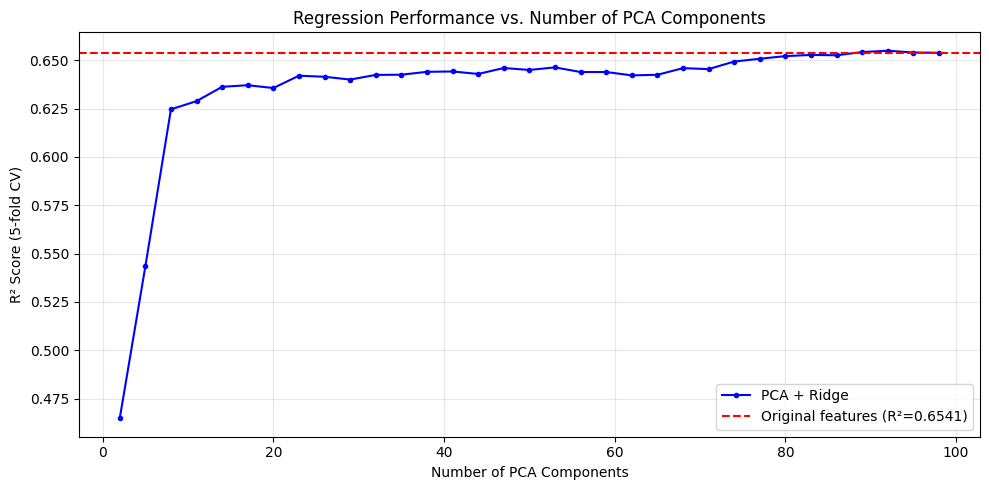

In [16]:
component_range = list(range(2, min(X_scaled.shape[1], 100), 3))
r2_scores = []

for n in component_range:
    pca_temp = PCA(n_components=n)
    X_temp = pca_temp.fit_transform(X_scaled)
    score = cross_val_score(Ridge(alpha=1.0), X_temp, y, cv=cv, scoring='r2').mean()
    r2_scores.append(score)

# Baseline: original features
baseline_r2 = scores_orig.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(component_range, r2_scores, 'b-o', markersize=3, label='PCA + Ridge')
ax.axhline(y=baseline_r2, color='r', linestyle='--', label=f'Original features (R²={baseline_r2:.4f})')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('R² Score (5-fold CV)')
ax.set_title('Regression Performance vs. Number of PCA Components')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/task5_performance_vs_components.pdf', dpi=150, bbox_inches='tight')
plt.show()

### Feature loadings heatmap - PCA Interpretability

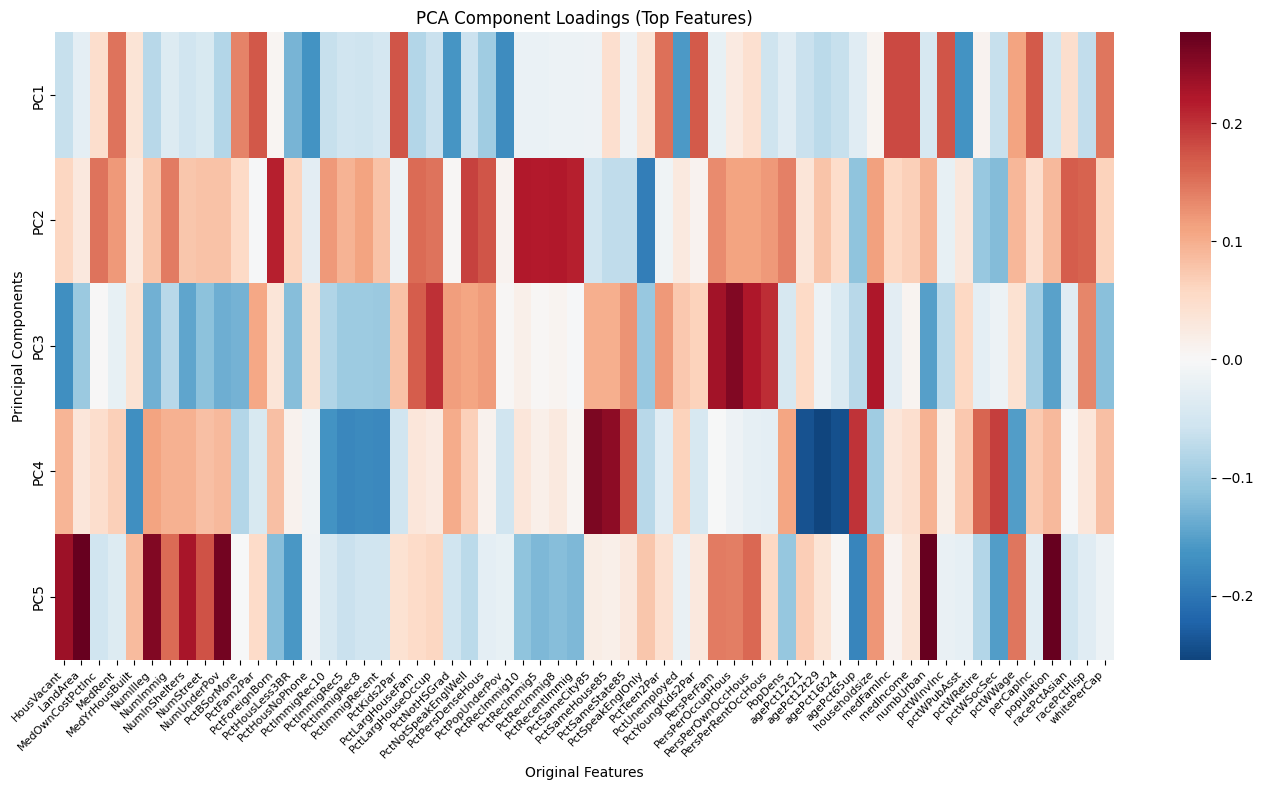

In [18]:
n_show = 5  # top PCs to show
n_features_show = 15  # top features per PC

fig, ax = plt.subplots(figsize=(14, 8))
loadings_df = pd.DataFrame(
    pca.components_[:n_show, :],
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_show)]
)

# Select top features by absolute loading across first 5 PCs
top_features = set()
for i in range(n_show):
    abs_loadings = np.abs(pca.components_[i])
    top_idx = np.argsort(abs_loadings)[-n_features_show:]
    top_features.update([feature_names[j] for j in top_idx])

top_features = sorted(top_features)
loadings_subset = loadings_df[top_features]

sns.heatmap(loadings_subset, cmap='RdBu_r', center=0, annot=False,
            fmt='.2f', ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('PCA Component Loadings (Top Features)')
ax.set_xlabel('Original Features')
ax.set_ylabel('Principal Components')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/task5_pca_loadings_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()

### Explainability Analysis

RF on Original features: R² = 0.6184
RF on PCA features:      R² = 0.6129

Top 10 most important features (RF on original):
  PctIlleg: 0.3275
  PctKids2Par: 0.2123
  racePctWhite: 0.0285
  PctFam2Par: 0.0228
  NumIlleg: 0.0144
  FemalePctDiv: 0.0132
  NumStreet: 0.0117
  MalePctDivorce: 0.0110
  PctPersDenseHous: 0.0109
  HousVacant: 0.0106

Top 10 most important PCA components (RF on PCA):
  PC1: 0.4394
  PC3: 0.0876
  PC2: 0.0479
  PC7: 0.0476
  PC8: 0.0400
  PC15: 0.0172
  PC32: 0.0165
  PC4: 0.0145
  PC5: 0.0141
  PC10: 0.0139


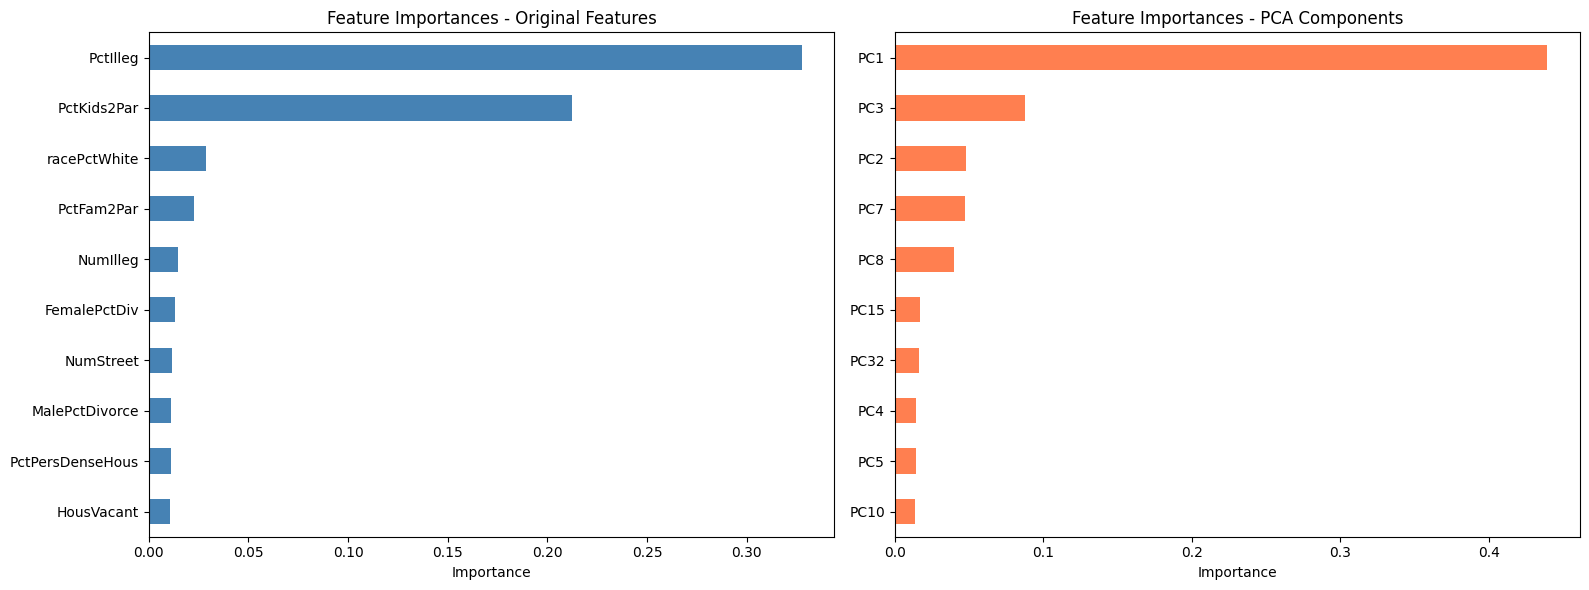

In [19]:
# Train models for SHAP analysis
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# PCA transform
pca_explain = PCA(n_components=n_95)
X_train_pca = pca_explain.fit_transform(X_train)
X_test_pca = pca_explain.transform(X_test)

# Original model - feature importances
rf_explain = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_explain.fit(X_train, y_train)
r2_orig = r2_score(y_test, rf_explain.predict(X_test))

# PCA model
rf_pca_explain = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca_explain.fit(X_train_pca, y_train)
r2_pca = r2_score(y_test, rf_pca_explain.predict(X_test_pca))

print(f"RF on Original features: R² = {r2_orig:.4f}")
print(f"RF on PCA features:      R² = {r2_pca:.4f}")

# Feature importances - Original
importances = pd.Series(rf_explain.feature_importances_, index=feature_names)
top_10 = importances.nlargest(10)
print(f"\nTop 10 most important features (RF on original):")
for name, imp in top_10.items():
    print(f"  {name}: {imp:.4f}")

# Feature importances - PCA (less interpretable!)
pca_importances = pd.Series(rf_pca_explain.feature_importances_,
                            index=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
top_pca = pca_importances.nlargest(10)
print(f"\nTop 10 most important PCA components (RF on PCA):")
for name, imp in top_pca.items():
    print(f"  {name}: {imp:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_10.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances - Original Features')
axes[0].set_xlabel('Importance')

top_pca.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Importances - PCA Components')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../figures/task5_feature_importances.pdf', dpi=150, bbox_inches='tight')
plt.show()

### Mapping PCA back to original features

In [20]:
# For the top 3 most important PCs, show what original features they represent
top_3_pcs = pca_importances.nlargest(3).index.tolist()
for pc_name in top_3_pcs:
    pc_idx = int(pc_name.replace('PC', '')) - 1
    loadings = pd.Series(pca_explain.components_[pc_idx], index=feature_names)
    print(f"\n{pc_name} (importance={pca_importances[pc_name]:.4f}, "
          f"variance explained={pca_explain.explained_variance_ratio_[pc_idx]*100:.1f}%):")
    top_pos = loadings.nlargest(5)
    top_neg = loadings.nsmallest(5)
    print(f"  Positive loadings: {', '.join([f'{n}({v:.3f})' for n, v in top_pos.items()])}")
    print(f"  Negative loadings: {', '.join([f'{n}({v:.3f})' for n, v in top_neg.items()])}")


PC1 (importance=0.4394, variance explained=24.7%):
  Positive loadings: medFamInc(0.180), medIncome(0.178), PctKids2Par(0.175), pctWInvInc(0.174), PctYoungKids2Par(0.172)
  Negative loadings: PctPopUnderPov(-0.173), pctWPubAsst(-0.165), PctHousNoPhone(-0.165), PctNotHSGrad(-0.162), PctUnemployed(-0.157)

PC3 (importance=0.0876, variance explained=9.7%):
  Positive loadings: PersPerOccupHous(0.254), householdsize(0.230), PersPerFam(0.230), PersPerOwnOccHous(0.224), PersPerRentOccHous(0.209)
  Negative loadings: HousVacant(-0.184), numbUrban(-0.165), NumInShelters(-0.163), population(-0.163), NumIlleg(-0.152)

PC2 (importance=0.0479, variance explained=16.8%):
  Positive loadings: PctRecImmig10(0.218), PctRecImmig8(0.218), PctRecImmig5(0.216), PctRecentImmig(0.213), PctForeignBorn(0.212)
  Negative loadings: PctSpeakEnglOnly(-0.189), PctBornSameState(-0.126), pctWSocSec(-0.117), racePctWhite(-0.112), agePct65up(-0.108)


### Summary Table

In [21]:
pd.DataFrame({
    'Method': ['Original', f'PCA (10 comp)', f'PCA (20 comp)', f'PCA ({n_95} comp, 95%)',
               'LDA (classification)'],
    'Dimensions': [X_scaled.shape[1], 10, 20, n_95, max_lda_components],
    'Reduction %': [0,
                    round((1 - 10/X_scaled.shape[1])*100, 1),
                    round((1 - 20/X_scaled.shape[1])*100, 1),
                    round((1 - n_95/X_scaled.shape[1])*100, 1),
                    round((1 - max_lda_components/X_scaled.shape[1])*100, 1)],
    'Interpretable': ['Yes - direct features', 'Limited - linear combos',
                      'Limited - linear combos', 'Limited - linear combos',
                      'Limited - class-driven combos'],
})

,Method,Dimensions,Reduction %,Interpretable
0,Original,100,0.0,Yes - direct features
1,PCA (10 comp),10,90.0,Limited - linear combos
2,PCA (20 comp),20,80.0,Limited - linear combos
3,"PCA (35 comp, 95%)",35,65.0,Limited - linear combos
4,LDA (classification),4,96.0,Limited - class-driven combos


# Task 2: Model comparison

**Task:** Compare parametric and nonparametric models for your chosen problem, selecting at least three methods from each group. Evaluate which class offers stronger explainability and reproducibility and justify why.

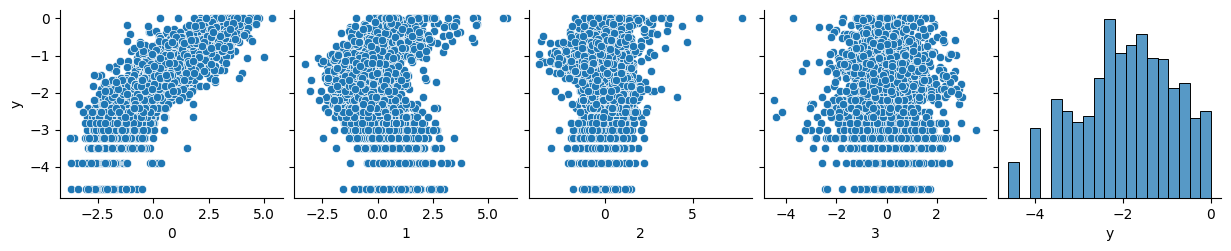

In [47]:
sns.pairplot(pd.concat([pd.DataFrame(X_lda), pd.Series(np.log(y), name="y")], axis=1), y_vars=["y"])

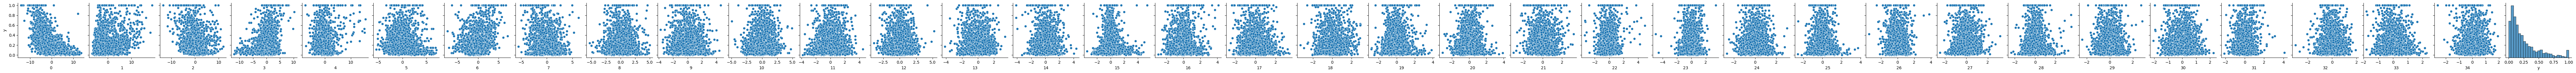

In [10]:
sns.pairplot(pd.concat([pd.DataFrame(X_pca), pd.Series(y, name="y")], axis=1), y_vars=["y"])

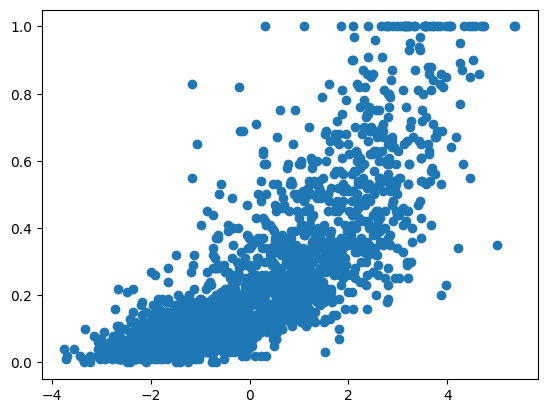

In [34]:
plt.scatter(X_lda[:,0], y)
plt.show()

First, we'll try out all models with both original data and the dimensionaly reduced datasets. The defaults setting will be kept for now, they will be refined where applicable based on the initial results.

In [8]:
from typing import Any, Union

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

Estimator = Union[PLSRegression, ElasticNetCV, LinearRegression, DecisionTreeRegressor, RandomForestRegressor, KNeighborsRegressor]

models = {
    "parametric": [
        # Partial least squares regression should handle the large amount of features. It reduces
        # the predictors by also using the response value, so it may have better results that just
        # learning on features reduced without supervision. Keep 4 components from normal PCA.
        PLSRegression(n_components=4),
        # Elastic net combines L1 and L2 regularisation from lasso and ridge methods while
        # reportedly being more accurate than both. ElasticNetCV should find the correct values of
        # `alpha` and `l1_ratio`.
        ElasticNetCV(n_jobs=-1),
        # I expect linear regression to have problems, considering the large amount of features with
        # high collinearity, but using the reduced feature space, it may produce good outputs while
        # having high explainability.
        LinearRegression(),
    ],
    "nonparametric": [
        # Despite being nonparametric, a decision tree is simple to explain.
        DecisionTreeRegressor(),
        # If a single decision tree is insufficient, a random forest may be required. Random forest
        # also provides a validation set from OOB samples, but in the interest of having universal
        # testing code we're not going to use it.
        RandomForestRegressor(oob_score=False, n_jobs=-1),
        # Another attempt to improve decision tree performance (by default gradient boosting uses decision trees).
        GradientBoostingRegressor(),
        # kNN will be probably hopeless with the full dataset, but with the dimensionality reduced
        # datasets it could work. kNN regression is good when there are clusters of similar data,
        # but no global trend, which may be useful for this dataset which models human behaviour
        # across a large area.
        KNeighborsRegressor()
    ]
}


In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def test_model[T: Any](name: str, model: T, x = X_scaled, y = y) -> T:
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=9138)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name} : MSE: {mse:.4f}; R²: {r2:.4f}")

    return model

In [19]:
for x_name, x in [("all", X_scaled), ("lda", X_lda), ("pca", X_pca)]:
    print(f"-- {x_name}")
    for model in [*models["parametric"], *models["nonparametric"]]:
        test_model(model.__class__.__name__.split(".")[-1] + " + " + x_name, model, x)

-- all
PLSRegression + all : MSE: 0.0224; R²: 0.6267
ElasticNetCV + all : MSE: 0.0221; R²: 0.6328
LinearRegression + all : MSE: 0.0218; R²: 0.6373
DecisionTreeRegressor + all : MSE: 0.0412; R²: 0.3136
RandomForestRegressor + all : MSE: 0.0217; R²: 0.6391
GradientBoostingRegressor + all : MSE: 0.0215; R²: 0.6413
KNeighborsRegressor + all : MSE: 0.0245; R²: 0.5914
-- lda
PLSRegression + lda : MSE: 0.0199; R²: 0.6694
ElasticNetCV + lda : MSE: 0.0198; R²: 0.6697
LinearRegression + lda : MSE: 0.0199; R²: 0.6694
DecisionTreeRegressor + lda : MSE: 0.0375; R²: 0.3749
RandomForestRegressor + lda : MSE: 0.0216; R²: 0.6403
GradientBoostingRegressor + lda : MSE: 0.0211; R²: 0.6483
KNeighborsRegressor + lda : MSE: 0.0216; R²: 0.6397
-- pca
PLSRegression + pca : MSE: 0.0230; R²: 0.6172
ElasticNetCV + pca : MSE: 0.0229; R²: 0.6193
LinearRegression + pca : MSE: 0.0230; R²: 0.6172
DecisionTreeRegressor + pca : MSE: 0.0466; R²: 0.2247
RandomForestRegressor + pca : MSE: 0.0231; R²: 0.6155
GradientBoostin

### Performance of RandomForestRegressor

It seems dimensional reduction allowed the models to better fit the data. LDA displays the best results.

In [81]:
for i in range(50, 250, 50):
    test_model(f"Forest({i}) + lda", RandomForestRegressor(n_estimators=i), X_lda)

Forest(50) + lda : MSE: 0.0222; R²: 0.6308
Forest(100) + lda : MSE: 0.0214; R²: 0.6433
Forest(150) + lda : MSE: 0.0217; R²: 0.6389
Forest(200) + lda : MSE: 0.0215; R²: 0.6417


By default the `RandomForestRegressor` trains each tree on all samples. With `max_samples` this can adjusted.

In [18]:
for i in np.arange(0.1, 1, 0.1):
    test_model(f"Forest({i}, 100) + lda", RandomForestRegressor(oob_score=False, n_jobs=-1, max_samples=0.3, random_state=1445), X_lda)
    test_model(f"Forest({i}, 200) + lda", RandomForestRegressor(n_estimators=200, oob_score=False, n_jobs=-1, max_samples=0.3, random_state=1445), X_lda)

Forest(0.1, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.1, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.2, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.2, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.30000000000000004, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.30000000000000004, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.4, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.4, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.5, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.5, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.6, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.6, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.7000000000000001, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.7000000000000001, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.8, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.8, 200) + lda : MSE: 0.0204; R²: 0.6610
Forest(0.9, 100) + lda : MSE: 0.0206; R²: 0.6571
Forest(0.9, 200) + lda : MSE: 0.0204; R²: 0.6610


The percentage of samples does not seem to have any effect, it's just enabling the feature that improves performance.

Next parameter to evaluate is `criterion`. According to the documentation `absolute_error` has better results at the cost of taking longer to compute. For this small dataset, that should not be an issue.

In [25]:
for i in np.arange(0.1, 1, 0.1):
    test_model(f"Forest({i}, 100) + lda", RandomForestRegressor(oob_score=False, n_jobs=-1, max_samples=0.3, random_state=1445, criterion="absolute_error"), X_lda)
    test_model(f"Forest({i}, 200) + lda", RandomForestRegressor(n_estimators=200, oob_score=False, n_jobs=-1, max_samples=0.3, random_state=1445, criterion="absolute_error"), X_lda)

Forest(0.1, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.1, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.2, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.2, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.30000000000000004, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.30000000000000004, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.4, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.4, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.5, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.5, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.6, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.6, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.7000000000000001, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.7000000000000001, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.8, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.8, 200) + lda : MSE: 0.0200; R²: 0.6669
Forest(0.9, 100) + lda : MSE: 0.0201; R²: 0.6651
Forest(0.9, 200) + lda : MSE: 0.0200; R²: 0.6669


Unsurprisingly the `max_samples` parameters does not have effect with `absolute_error` either. Just to make sure, test it without the feature enabled.

In [26]:
test_model(f"Forest({i}, 200) + lda", RandomForestRegressor(n_estimators=200, oob_score=False, n_jobs=-1, random_state=1445, criterion="absolute_error"), X_lda)

Forest(0.9, 200) + lda : MSE: 0.0211; R²: 0.6481


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

Because the actual percentage does not matter, keep it at `0.3` like in examples. Final test with established parameters, just try to vary the number of trees.

In [27]:
for i in range(50, 350, 50):
    test_model(f"Forest({i}) + lda", RandomForestRegressor(n_estimators=i, oob_score=False, max_samples=0.3, n_jobs=-1, random_state=1445, criterion="absolute_error"), X_lda)

Forest(50) + lda : MSE: 0.0201; R²: 0.6647
Forest(100) + lda : MSE: 0.0201; R²: 0.6651
Forest(150) + lda : MSE: 0.0201; R²: 0.6652
Forest(200) + lda : MSE: 0.0200; R²: 0.6669
Forest(250) + lda : MSE: 0.0200; R²: 0.6669
Forest(300) + lda : MSE: 0.0200; R²: 0.6669


The performance only barely changes with these adjustments. No improvement after `200`, so keep it at that.

### Performance of GradientBoostingRegressor

### Performance of ElasticNetCV

In [30]:
for i in [5, 10, 15, 20]:
    test_model(f"Elastic(cv={i}) + lds", ElasticNetCV(cv=i, n_jobs=-1, random_state=1571), X_lda)

Elastic(cv=5) + lds : MSE: 0.0198; R²: 0.6697
Elastic(cv=10) + lds : MSE: 0.0198; R²: 0.6705
Elastic(cv=15) + lds : MSE: 0.0198; R²: 0.6696
Elastic(cv=20) + lds : MSE: 0.0198; R²: 0.6696


`ElasticNetCV` can also try out multiple L1 ratios, see if we can get a better result than with `0.5`.

In [39]:
for i in [5, 10, 15, 20]:
    print((model := test_model(f"Elastic(cv={i}) + lda", ElasticNetCV(cv=i, l1_ratio=[0.1, 0.2, 0.5, 0.7, 0.9, 0.95, 0.99, 1], n_jobs=-1, random_state=1571), X_lda)).l1_ratio_, model.alpha_)
    

Elastic(cv=5) + lda : MSE: 0.0198; R²: 0.6696
0.1 0.004345970486264325
Elastic(cv=10) + lda : MSE: 0.0198; R²: 0.6706
1.0 0.002017220808025518
Elastic(cv=15) + lda : MSE: 0.0198; R²: 0.6696
0.1 0.003287567295493721
Elastic(cv=20) + lda : MSE: 0.0198; R²: 0.6696
0.2 0.0016437836477468605


In [11]:
for i in [5, 10, 15, 20]:
    print((model := test_model(f"Elastic(cv={i}) + all", ElasticNetCV(cv=i, l1_ratio=[0.01, 0.1, 0.2, 0.5, 0.7, 0.9, 0.95, 0.99, 1], n_jobs=-1, random_state=1571), X_scaled)).l1_ratio_, model.alpha_)
    

Elastic(cv=5) + all : MSE: 0.0220; R²: 0.6331
0.01 0.02407407829708495
Elastic(cv=10) + all : MSE: 0.0220; R²: 0.6334
0.01 0.016983786319869652
Elastic(cv=15) + all : MSE: 0.0220; R²: 0.6334
0.01 0.016983786319869652
Elastic(cv=20) + all : MSE: 0.0220; R²: 0.6334
0.01 0.016983786319869652


Considering the best result for LDA reduced dataset has `l1_ratio` of `1.0`, we can just use a LASSO model for equivalent performance, and because the best results for all features has `l1_ratio` of `0.01`, we can conclude that we can use Ridge model for best performance with said dataset.

In [16]:
from sklearn.linear_model import ElasticNet, Lasso


print(test_model("Lasso + lda", Lasso(alpha=0.002017220808025518, random_state=1571), X_lda).coef_)
print(test_model("Ridge + lda", Ridge(alpha=0.004345970486264325, random_state=1571), X_lda).coef_)
print(test_model("ElasticNet(L1 = 90%) + lda", ElasticNet(alpha=0.002017220808025518, l1_ratio=0.9, random_state=1571), X_lda).coef_)
test_model("Lasso + all", Lasso(alpha=0.016983786319869652, random_state=1571), X_scaled)
test_model("Ridge + all", Ridge(alpha=0.016983786319869652, random_state=1571), X_scaled)

Lasso + lda : MSE: 0.0198; R²: 0.6706
[0.10298082 0.03714345 0.01525706 0.00071309]
Ridge + lda : MSE: 0.0199; R²: 0.6694
[0.10365222 0.03874329 0.01724502 0.00266669]
ElasticNet(L1 = 90%) + lda : MSE: 0.0198; R²: 0.6705
[0.10304133 0.03729729 0.0154527  0.00090826]
Lasso + all : MSE: 0.0235; R²: 0.6086
Ridge + all : MSE: 0.0218; R²: 0.6372


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.016983786319869652
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average 

Out of curiosity, compare the coefficients with simple linear regression. The use of regularisation is used to handle colinearity and there shouldn't be colinearity in the LDA reduced dataset.

In [ ]:
print(test_model("LinearRegression + lda", LinearRegression(), X_lda).coef_)


LinearRegression + lda : MSE: 0.0199; R²: 0.6694
[0.10365231 0.03874338 0.01724507 0.0026667 ]
LinearRegression + lda : MSE: 0.0198; R²: 0.6707
[0.10365289 0.03876274 0.01717409]


The biggest difference between coefficients is the very small weight of the last feature. Try to remove it.

In [ ]:

print(test_model("LinearRegression + lda", LinearRegression(), X_lda[:, 0:3]).coef_)

### Performance of KNeighborsRegressor

In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [1, 5, 10, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring="neg_mean_squared_error")
grid.fit(X_lda, y)

print(f"Best parameters: {grid.best_params_}")

Best parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}


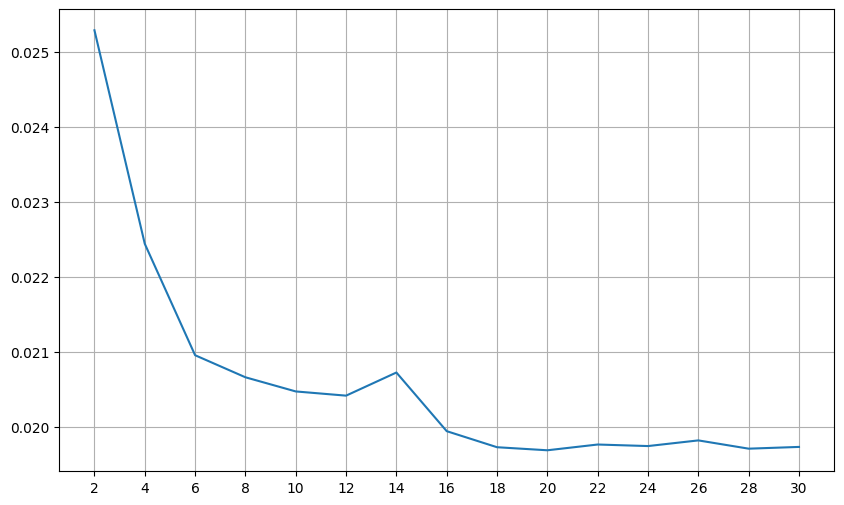

In [61]:
plot_x = []
plot_y = []

for k in range(2, 32, 2):
    model = KNeighborsRegressor(weights="distance", metric="euclidean", n_neighbors=k)
    X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=9138)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    plot_x.append(k)
    plot_y.append(mse)

plt.figure(figsize=(10, 6))
plt.xticks(plot_x)
plt.grid(True)
plt.plot(plot_x, plot_y)
plt.show()

I'll just round `k` it up to `20`.

In [60]:
test_model("kNN + lda", KNeighborsRegressor(weights="distance", metric="euclidean", n_neighbors=20), X_lda)

kNN + lda : MSE: 0.0197; R²: 0.6722


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Explainability & Reproducibility

In terms of explainability, the ElasticNetCV model is the best. Because it uses linear regression, we can simply look at how much each feature impacts the resulting value. This won't work very well with all features, where collinearity makes it hard to trust the individual coefficients, it will be useful with LDA dimensionality reduction, where the LDA features can be mapped back to the original ones.

For reproducibility it is more complicated: when using all features the ElasticNetCV has determined that the best `l1_ratio` is `0.01`, which means it mostly uses L2 regularisation that evenly splits coefficients between colinear features — in this case the reproducibility is good, but harms interpretability, but with LDA dimensionality reduction, the best performance is achieved with `l1_ratio` of `1`, therefore L1 regularisation will be used, and in cases of collinearity, one feature will be picked arbitrarily and others suppressed. But that is unlikely to matter, because there shouldn't be colinear features in the dimensionally reduced dataset anyway — in that case the reproducibility relies on the reproducibility of LDA.

But, as experiments show, manually removing the least significant feature from the dimensionally reduced dataset makes `LinearRegression` achieve comparable performance. It stands to reason that this would be the most explainable and reproducible model if LDA was reproducible.

Honourable mention to DecisionTreeRegressor which is also very explainable, but has significantly inferior performance. Improvements upon it, like RandomForestRegressor could be used for interpretation, using Gini importance for each feature across the whole forrest. KNeighborsRegressor has great performance but does not help understand the data at all.

**In conclusion:** For best **explainability** we would use the `LinearRegression` model with the first three most significant features from LDA. This provides the best performance while showing the coefficients for each feature which can be mapped back to the original features. For **reproducibility** the Ridge model trained on all features would be best.



### Conclusions from Explainability

In [ ]:
reg = test_model(f"Lasso + lda", Lasso(alpha=0.002017220808025518), X_lda)
print(reg.coef_)

# The 'scalings_' attribute shows the contribution of original features to the LDA components.
loadings = lda.scalings_

# Weight the loadings by the regression coefficients
weighted_loadings = loadings * reg.coef_

# Create a DataFrame for easier viewing
feature_names = [f"Feature {i}" for i in range(X_scaled.shape[1])] # Replace with real names
df_loadings = pd.DataFrame(weighted_loadings, index=X.columns, columns=[f'LD{i+1}' for i in range(loadings.shape[1])])
# Leave out the last feature as it is evidently not useful.
df_loadings = df_loadings.drop(("LD4"), axis=1)

# Calculate absolute importance (sum of weights across components)
df_loadings['Abs_Importance'] = df_loadings.abs().sum(axis=1)
df_loadings = df_loadings.sort_values(by='Abs_Importance', ascending=False)
df_loadings.head(10)

Lasso + lda : MSE: 0.0198; R²: 0.6706
[0.10298082 0.03714345 0.01525706 0.00071309]


,LD1,LD2,LD3,Abs_Importance
population,0.142771,-0.125774,-0.028501,0.297047
numbUrban,-0.105439,0.106128,0.027874,0.239441
PctRecImmig10,-0.162425,0.032614,0.040594,0.235633
PctRecImmig8,0.171953,-0.003348,-0.012246,0.187546
PersPerOccupHous,0.107526,0.029468,-0.030034,0.167028
TotalPctDiv,-0.064992,0.012991,-0.088179,0.166162
PctPersOwnOccup,-0.111482,-0.039965,0.005175,0.156622
PctKids2Par,-0.121144,0.023418,-0.006247,0.150809
PctHousOwnOcc,0.094144,0.028943,-0.003093,0.126180
medFamInc,0.103265,-0.008301,0.007417,0.118983


In [22]:
df_loadings.sort_values(by="LD1", key=abs, ascending=False).head(10)

,LD1,LD2,LD3,Abs_Importance
PctRecImmig8,0.171953,-0.003348,-0.012246,0.187546
PctRecImmig10,-0.162425,0.032614,0.040594,0.235633
population,0.142771,-0.125774,-0.028501,0.297047
PctKids2Par,-0.121144,0.023418,-0.006247,0.150809
PctPersOwnOccup,-0.111482,-0.039965,0.005175,0.156622
PersPerOccupHous,0.107526,0.029468,-0.030034,0.167028
numbUrban,-0.105439,0.106128,0.027874,0.239441
medFamInc,0.103265,-0.008301,0.007417,0.118983
PctHousOwnOcc,0.094144,0.028943,-0.003093,0.126180
medIncome,-0.082460,0.018286,-0.016827,0.117573


In [23]:
df_loadings.sort_values(by="LD2", key=abs, ascending=False).head(10)

,LD1,LD2,LD3,Abs_Importance
population,0.142771,-0.125774,-0.028501,0.297047
numbUrban,-0.105439,0.106128,0.027874,0.239441
MedRent,0.021451,0.055913,0.000753,0.078117
OwnOccMedVal,0.005762,0.051399,-0.010109,0.067270
PersPerRentOccHous,-0.020410,-0.042387,0.008783,0.071581
PctPersOwnOccup,-0.111482,-0.039965,0.005175,0.156622
RentHighQ,0.007138,-0.039025,0.003382,0.049545
OwnOccLowQuart,-0.050218,-0.033429,0.014117,0.097764
PctRecImmig10,-0.162425,0.032614,0.040594,0.235633
pctWInvInc,-0.058583,0.029994,-0.009030,0.097607


In [24]:
df_loadings.sort_values(by="LD3", key=abs, ascending=False).head(10)

,LD1,LD2,LD3,Abs_Importance
TotalPctDiv,-0.064992,0.012991,-0.088179,0.166162
FemalePctDiv,0.028607,-0.010052,0.050655,0.089314
PctRecImmig10,-0.162425,0.032614,0.040594,0.235633
MalePctDivorce,0.057064,-0.012372,0.037113,0.106549
PersPerOccupHous,0.107526,0.029468,-0.030034,0.167028
population,0.142771,-0.125774,-0.028501,0.297047
numbUrban,-0.105439,0.106128,0.027874,0.239441
PctRecImmig5,-0.012921,-0.021144,-0.025311,0.059375
perCapInc,-0.001044,0.007408,0.023659,0.032112
PersPerOwnOccHous,-0.015332,-0.023805,0.018285,0.057422
